In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
abdallahwagih_emotion_dataset_path = kagglehub.dataset_download('abdallahwagih/emotion-dataset')

print('Data source import complete.')


Using Colab cache for faster access to the 'emotion-dataset' dataset.
Data source import complete.


# Importing libraries, loading and transforming data

In [ ]:
# The following line uses the 'pip' package manager to install or update several Python packages.
# - '-U' stands for 'upgrade,' ensuring the packages are updated if they are already installed.
# - '-q' stands for 'quiet,' which suppresses output messages during installation.
# - 'mlflow' is being installed or updated, a platform for managing machine learning experiments.
# - 'datasets' is being installed or updated, a library for easily working with various datasets.
# - 'nlp' is being installed or updated, which is likely a specific version or extension of the 'datasets' library.
# - 'evaluate' is being installed or updated, a library for easy access to evaluation metrics.
# - '2>/dev/null' redirects standard error (stderr) to /dev/null, effectively suppressing error messages from the installation process.

!pip install -U -q mlflow datasets>=2.14.5 nlp evaluate 2>/dev/null

In [ ]:
# Import necessary libraries
import pandas as pd  # For data manipulation and analysis
import gc  # For garbage collection to manage memory
import re  # For regular expressions
import numpy as np  # For numerical operations and arrays

import warnings  # For handling warnings
warnings.filterwarnings("ignore")  # Ignore warning messages

import torch  # PyTorch library for deep learning
from transformers import AutoModel, AutoTokenizer  # Transformers library for natural language processing
from transformers import pipeline, Trainer, TrainingArguments, DataCollatorWithPadding  # Transformers components for text processing
from transformers import AutoModelForSequenceClassification  # Transformer model for sequence classification

from nlp import Dataset  # Import custom 'Dataset' class for natural language processing tasks
from imblearn.over_sampling import RandomOverSampler  # For oversampling to handle class imbalance
import datasets  # Import datasets library
from datasets import Dataset, Image, ClassLabel  # Import custom 'Dataset', 'ClassLabel', and 'Image' classes
from transformers import pipeline  # Transformers library for pipelines
from bs4 import BeautifulSoup  # For parsing HTML content

import matplotlib.pyplot as plt  # For data visualization
import itertools  # For working with iterators
from sklearn.metrics import (
    accuracy_score,  # For calculating accuracy
    roc_auc_score,  # For ROC AUC score
    confusion_matrix,  # For confusion matrix
    classification_report,  # For classification report
    f1_score  # For F1 score
)

import evaluate  # Import evaluate library for loading metrics

from tqdm import tqdm  # For displaying progress bars
tqdm.pandas()  # Enable progress bars for pandas operations

In [ ]:
# Set parameters for training a news category classifier using DistilBERT

# Fraction of the dataset used for training, the rest will be used for validation
train_fraction = 0.8

# Number of training epochs
num_train_epochs = 20

# Learning rate
learning_rate = 2e-6

# Batch size for training
train_batch_size = 32

# Batch size for validation
eval_batch_size = 128

# Number of warm-up steps during training
warmup_steps = 50

# Weight decay to control regularization during training
weight_decay = 0.02

# Pre-trained BERT model to be used
BERT_MODEL = "bert-base-uncased"

# Directory where the model output will be saved
output_dir = "text-emotion-classifier-distilbert"

In [ ]:
%%time
df = pd.read_csv('train.csv')  # Read the CSV file into a DataFrame
item0 = df.shape[0]  # Store the initial number of items in the DataFrame
df = df.drop_duplicates()  # Remove duplicate rows from the DataFrame
item1 = df.shape[0]  # Store the number of items in the DataFrame after removing duplicates
print(f"There are {item0-item1} duplicates found in the dataset")  # Print the number of duplicates removed


df = df.rename(columns={'text': 'title'})  # Rename the 'text' column to 'title'

df = df[['label', 'title']]  # Select only the 'label' and 'title' columns
df = df[~df['title'].isnull()]  # Remove rows where 'title' is null
df = df[~df['label'].isnull()]  # Remove rows where 'label' is null

print(df.shape)  # Print the shape of the DataFrame after data preprocessing
df.sample(5).T  # Display a random sample of 5 rows from the DataFrame

There are 299006 duplicates found in the dataset
(434, 2)
CPU times: user 400 ms, sys: 25.1 ms, total: 425 ms
Wall time: 657 ms


,30,169,272,55,101
label,1,1,6,7,7
title,im alone i feel awful,i woke up half way home and vaguely remember f...,it was in march when one of my fellow students...,i sincerely believe that every client celebrit...,i just supposed to read the bible and think we...


In [ ]:
# random oversampling of minority class(es)
# 'y' contains the target variable (label) we want to predict
y = df[['label']]

# Drop the 'label' column from the DataFrame 'df' to separate features from the target variable
df = df.drop(['label'], axis=1)

# Create a RandomOverSampler object with a specified random seed (random_state=83)
ros = RandomOverSampler(random_state=83)

# Use the RandomOverSampler to resample the dataset by oversampling the minority class
# 'df' contains the feature data, and 'y_resampled' will contain the resampled target variable
df, y_resampled = ros.fit_resample(df, y)

# Delete the original 'y' variable to save memory as it's no longer needed
del y

# Add the resampled target variable 'y_resampled' as a new 'label' column in the DataFrame 'df'
df['label'] = y_resampled

# Delete the 'y_resampled' variable to save memory as it's no longer needed
del y_resampled

# Perform garbage collection to free up memory used by discarded variables
gc.collect()

print(df.shape)

(1000, 2)


In [ ]:
# Create a list of unique labels, ensuring they are standard Python integers
labels_list = sorted([int(x) for x in df['label'].unique()])

# Initialize empty dictionaries to map labels to IDs and vice versa
label2id, id2label = dict(), dict()

# Iterate over the unique labels and assign each label an ID, and vice versa
for i, label in enumerate(labels_list):
    label2id[label] = i  # Map the label to its corresponding ID
    id2label[i] = label  # Map the ID to its corresponding label

# Print the resulting dictionaries for reference
print("Mapping of IDs to Labels:", id2label, '\n')
print("Mapping of Labels to IDs:", label2id)

Mapping of IDs to Labels: {0: 1, 1: 2, 2: 3, 3: 4, 4: 5, 5: 6, 6: 7, 7: 8} 

Mapping of Labels to IDs: {1: 0, 2: 1, 3: 2, 4: 3, 5: 4, 6: 5, 7: 6, 8: 7}


In [ ]:
# Create a dataset from the Pandas DataFrame 'df'
dataset = Dataset.from_pandas(df)

In [ ]:
# Creating classlabels to match labels to IDs
ClassLabels = ClassLabel(num_classes=len(labels_list), names=labels_list)

# Mapping labels to IDs
def map_label2id(example):
    example['label'] = ClassLabels.str2int(example['label'])
    return example

dataset = dataset.map(map_label2id, batched=True)

# Casting label column to ClassLabel Object
dataset = dataset.cast_column('label', ClassLabels)

# Splitting the dataset into training and testing sets using an 80-20 split ratio.
# This operation returns a DatasetDict.
dataset_splits = dataset.train_test_split(test_size=0.2, shuffle=True, stratify_by_column="label")

# Extracting the training data from the split dataset.
df_train = dataset_splits['train']

# Extracting the testing data from the split dataset.
df_test = dataset_splits['test']

# Rename the 'label' column to 'labels' as expected by the Trainer
df_train = df_train.rename_column("label", "labels")
df_test = df_test.rename_column("label", "labels")

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [ ]:
# Deleting the DataFrame 'df'
del df

# Performing garbage collection to free up memory
gc.collect()

410

In [ ]:
# Create a tokenizer instance for the specified BERT model.
# - 'AutoTokenizer.from_pretrained' loads the pre-trained tokenizer for the specified model.
# - 'use_fast=True' enables fast tokenization, which is recommended for most use cases.
# - 'low_cpu_mem_usage=False' disables low CPU memory usage mode (useful for larger models).
tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL, use_fast=True, low_cpu_mem_usage=False)

In [ ]:
# Importantly, this is a simple function for preprocessing data before training a natural language processing model.
# It takes a dataset of examples as input.

def preprocess_function(examples):
    # The main task of this function is to tokenize the text data in the 'title' column of the examples.
    # Tokenization is the process of breaking down text into smaller units, such as words or subwords.
    # In this case, the tokenizer is applied to each 'title' in the examples.

    # The 'truncation=True' parameter indicates that if a title is too long to fit within the model's maximum input length,
    # it should be truncated to fit. Truncation can help ensure that the input data is within the model's capacity.

    return tokenizer(examples["title"], truncation=True)

# The code below applies the preprocess_function to two dataframes, df_train and df_test.

# df_train is likely a training dataset, and df_test is likely a testing dataset.
# These datasets contain examples with a 'title' field that we want to tokenize for further processing.

# The 'map' function is used to apply the preprocess_function to each example in the datasets.
# The 'batched=True' parameter indicates that the tokenization should be applied in batches for efficiency.

df_train = df_train.map(preprocess_function, batched=True)
df_test = df_test.map(preprocess_function, batched=True)

Map:   0%|          | 0/800 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

In [ ]:
# Remove the 'title' column from the training dataset.
df_train = df_train.remove_columns(['title'])

# Remove the 'title' column from the testing dataset.
df_test = df_test.remove_columns(['title'])

In [ ]:
df_train

Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 800
})

In [ ]:
df_test

Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 200
})

In [ ]:
# DataCollatorWithPadding creates batch of data. It also dynamically pads text to the
#  length of the longest element in the batch, making them all the same length.
#  It's possible to pad your text in the tokenizer function with padding=True, dynamic padding is more efficient.
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [ ]:
# Retrieve the 'input_ids' from the first row of the DataFrame 'df_train'
tokenizer.decode(df_train[0]['input_ids'])

'[CLS] i want to capture this stillness and place it in a bottle so that the next time i m feeling a little gloomy i can take out this piece of tranquility and just breathe [SEP]'

# Loading and training model

In [ ]:
# Load a pre-trained BERT-based model for sequence classification.
model = AutoModelForSequenceClassification.from_pretrained(
    BERT_MODEL, num_labels=len(labels_list),
    output_attentions=False,  # Set to False: Model will not return attention weights.
    output_hidden_states=False  # Set to False: Model will not return all hidden-states.
)

# Configure the mapping of class labels to their corresponding indices for later reference.
model.config.id2label = id2label  # Mapping from label indices to class labels.
model.config.label2id = label2id  # Mapping from class labels to label indices.

# Calculate and print the number of trainable parameters in millions for the model.
print(model.num_parameters(only_trainable=True) / 1e6)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


109.488392


In [ ]:
# Import the 'load_metric' function from the Hugging Face datasets library to load a metric.
metric = evaluate.load("accuracy")

# Define a custom 'compute_metrics' function that will be used for evaluating model performance.
# This function takes 'eval_pred' as input, which is a tuple containing predicted logits and true labels.
def compute_metrics(eval_pred):
    # Unpack the 'eval_pred' tuple into 'logits' (predicted logits) and 'labels' (true labels).
    logits, labels = eval_pred

    # Calculate the model's predictions by selecting the class with the highest logit value.
    predictions = np.argmax(logits, axis=-1)

    # Use the imported metric to compute the accuracy of the model's predictions.
    accuracy = metric.compute(predictions=predictions, references=labels)

    # Return the computed accuracy as the evaluation metric.
    return accuracy

In [ ]:
# Create TrainingArguments to configure the training process
training_args = TrainingArguments(
    output_dir=output_dir,  # Directory to save the model checkpoints and logs
    logging_dir='./logs',  # Directory to store training logs
    num_train_epochs=num_train_epochs,  # Number of training epochs
    per_device_train_batch_size=train_batch_size,  # Batch size for training data
    per_device_eval_batch_size=eval_batch_size,  # Batch size for evaluation data
    logging_strategy='steps',  # Logging frequency during training (steps or epoch)
    logging_first_step=True,  # Log the first training step
    load_best_model_at_end=True,  # Load the best model at the end of training
    logging_steps=1,  # Log every training step (useful for debugging)
    learning_rate=learning_rate, # Set the learning rate for the optimizer.
    eval_strategy='epoch',  # Evaluation frequency (epoch or steps)
    warmup_steps=warmup_steps,  # Number of warmup steps for the learning rate
    weight_decay=weight_decay,  # Weight decay for regularization
    eval_steps=1,  # Evaluate every training step (useful for debugging)
    save_strategy='epoch',  # Save model checkpoints every epoch
    save_total_limit=1,  # Limit the number of saved checkpoints to save space
    report_to="mlflow",  # Log training metrics to MLflow
)

# Define the trainer:
# Instantiate the trainer class and configure its settings
trainer = Trainer(
    model=model,  # The pretrained or custom model to be trained
    args=training_args,  # TrainingArguments for configuring training
    compute_metrics=compute_metrics,  # Function for computing evaluation metrics
    train_dataset=df_train,  # Training dataset
    eval_dataset=df_test,  # Evaluation dataset
    data_collator=data_collator  # Data collator for batching and preprocessing
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
# Get initial metrics
trainer.evaluate()

{'eval_loss': 1.3291608095169067,
 'eval_model_preparation_time': 0.0072,
 'eval_accuracy': 0.62,
 'eval_runtime': 31.6138,
 'eval_samples_per_second': 6.326,
 'eval_steps_per_second': 0.063,
 'epoch': 20.0}

In [ ]:
# Start training the model
trainer.train()

Epoch,Training Loss,Validation Loss,Model Preparation Time,Accuracy
1,2.178477,2.146055,0.007200,0.000000
2,1.953981,1.989057,0.007200,0.290000
3,1.893032,1.838932,0.007200,0.480000
4,1.776135,1.739305,0.007200,0.485000
5,1.573097,1.681992,0.007200,0.485000
6,1.577068,1.626171,0.007200,0.490000
7,1.801997,1.579025,0.007200,0.500000
8,1.670983,1.533446,0.007200,0.500000
9,1.487034,1.495433,0.007200,0.530000
10,1.414057,1.460113,0.007200,0.545000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=500, training_loss=1.576693135023117, metrics={'train_runtime': 7127.9308, 'train_samples_per_second': 2.245, 'train_steps_per_second': 0.07, 'total_flos': 411692312312832.0, 'train_loss': 1.576693135023117, 'epoch': 20.0})

In [ ]:
# Final model evaluation
trainer.evaluate()

{'eval_loss': 1.3291608095169067,
 'eval_model_preparation_time': 0.0072,
 'eval_accuracy': 0.62,
 'eval_runtime': 28.1499,
 'eval_samples_per_second': 7.105,
 'eval_steps_per_second': 0.071,
 'epoch': 20.0}

In [ ]:
# Use the trained 'trainer' to make predictions on the 'df_test'.
outputs = trainer.predict(df_test)

# Print the metrics obtained from the prediction outputs.
print(outputs.metrics)

{'test_loss': 1.3291608095169067, 'test_model_preparation_time': 0.0072, 'test_accuracy': 0.62, 'test_runtime': 26.3383, 'test_samples_per_second': 7.594, 'test_steps_per_second': 0.076}


Accuracy: 0.6200
F1 Score: 0.4428


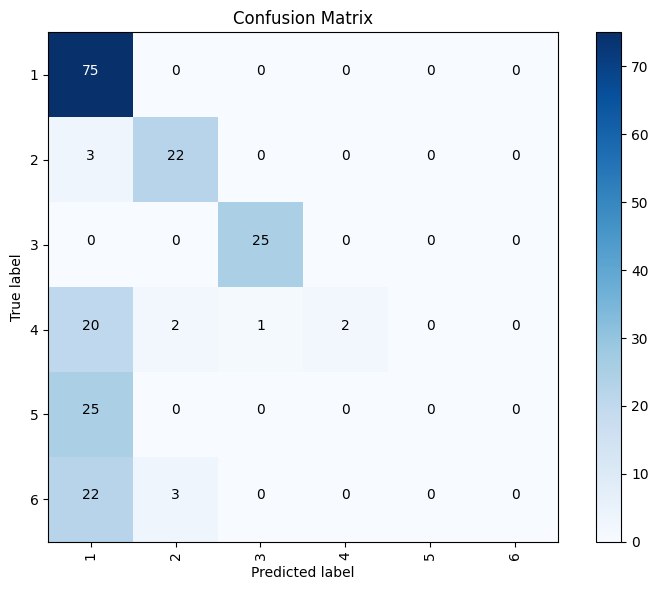


Classification report:

              precision    recall  f1-score   support

           1     0.5172    1.0000    0.6818        75
           2     0.8148    0.8800    0.8462        25
           3     0.9615    1.0000    0.9804        25
           4     1.0000    0.0800    0.1481        25
           5     0.0000    0.0000    0.0000        25
           6     0.0000    0.0000    0.0000        25

    accuracy                         0.6200       200
   macro avg     0.5489    0.4933    0.4428       200
weighted avg     0.5410    0.6200    0.5025       200



In [ ]:
# Extract the true labels from the model outputs
y_true = outputs.label_ids

# Predict the labels by selecting the class with the highest probability
y_pred = outputs.predictions.argmax(1)

# Define a function to plot a confusion matrix
def plot_confusion_matrix(cm, classes, title='Confusion Matrix', cmap=plt.cm.Blues, figsize=(10, 8)):
    """
    This function plots a confusion matrix.

    Parameters:
        cm (array-like): Confusion matrix as returned by sklearn.metrics.confusion_matrix.
        classes (list): List of class names, e.g., ['Class 0', 'Class 1'].
        title (str): Title for the plot.
        cmap (matplotlib colormap): Colormap for the plot.
    """
    # Create a figure with a specified size
    plt.figure(figsize=figsize)

    # Display the confusion matrix as an image with a colormap
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()

    # Define tick marks and labels for the classes on the axes
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=90)
    plt.yticks(tick_marks, classes)

    fmt = '.0f'
    # Add text annotations to the plot indicating the values in the cells
    thresh = cm.max() / 2.0
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt), horizontalalignment="center", color="white" if cm[i, j] > thresh else "black")

    # Label the axes
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

    # Ensure the plot layout is tight
    plt.tight_layout()
    # Display the plot
    plt.show()

# Calculate accuracy and F1 score
accuracy = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average='macro')

# Display accuracy and F1 score
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")

# Get the confusion matrix if there are a relatively small number of labels
if len(labels_list) <= 120:
    # Compute the confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Determine the unique labels present in the true values (0-indexed IDs)
    unique_labels_in_test = np.unique(y_true)

    # Create target names corresponding to these unique labels using id2label mapping
    # id2label maps 0-indexed IDs to original labels (e.g., 0:1, 1:2)
    # Convert original labels to strings for display in target_names
    target_names_for_report = [str(id2label[label_id]) for label_id in unique_labels_in_test]

    # Plot the confusion matrix using the defined function
    plot_confusion_matrix(cm, target_names_for_report, figsize=(8, 6)) # Pass the relevant target names for plotting

# Finally, display classification report
print()
print("Classification report:")
print()
print(classification_report(y_true, y_pred, labels=unique_labels_in_test, target_names=target_names_for_report, digits=4))

In [ ]:
trainer.save_model()

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
tokenizer.save_vocabulary(save_directory=f"./{output_dir}")

('./text-emotion-classifier-distilbert/tokenizer.model',)

In [ ]:
# Make a classification pipeline and test with the sample input
pipe = pipeline("text-classification", output_dir, tokenizer=BERT_MODEL)
sample_title = '''Elon Musk buys Twitter'''
pipe(sample_title, top_k=10)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[{'label': 1, 'score': 0.19585128128528595},
 {'label': 3, 'score': 0.1956513375043869},
 {'label': 2, 'score': 0.1482664942741394},
 {'label': 4, 'score': 0.1366022378206253},
 {'label': 6, 'score': 0.12363287806510925},
 {'label': 5, 'score': 0.10070911794900894},
 {'label': 8, 'score': 0.05157861113548279},
 {'label': 7, 'score': 0.04770806431770325}]

In [ ]:
# finally, save the model to Huggingface
from huggingface_hub import notebook_login
notebook_login()

In [ ]:
from huggingface_hub import HfApi
api = HfApi()
repo_id = f"dima806/{output_dir}"
try:
    api.create_repo(repo_id)
    print(f"Repo {repo_id} created")
except:
    print(f"Repo {repo_id} already exists")

Repo dima806/text-emotion-classifier-distilbert already exists


In [ ]:
api.upload_folder(
    folder_path=output_dir,
    path_in_repo = ".",
    repo_id=repo_id,
    repo_type="model"
)

HfHubHTTPError: (Request ID: Root=1-69d8da31-04f184962618dd887ace2a7c;c579b836-22e0-4344-820a-bb0dcc905d63)

403 Forbidden: You have read access but not the required permissions for this operation.
Cannot access content at: https://huggingface.co/dima806/text-emotion-classifier-distilbert.git/info/lfs/objects/batch.
Make sure your token has the correct permissions.

# Saving the model and checking its performance with a sample input

In [ ]:
trainer.save_model()

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
tokenizer.save_vocabulary(save_directory=f"./{output_dir}")

('./text-emotion-classifier-distilbert/tokenizer.model',)

In [ ]:
# Make a classification pipeline and test with the sample input
pipe = pipeline("text-classification", output_dir, tokenizer=BERT_MODEL)
sample_title = '''Elon Musk buys Twitter'''
pipe(sample_title, top_k=10)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[{'label': 1, 'score': 0.19585128128528595},
 {'label': 3, 'score': 0.1956513375043869},
 {'label': 2, 'score': 0.1482664942741394},
 {'label': 4, 'score': 0.1366022378206253},
 {'label': 6, 'score': 0.12363287806510925},
 {'label': 5, 'score': 0.10070911794900894},
 {'label': 8, 'score': 0.05157861113548279},
 {'label': 7, 'score': 0.04770806431770325}]

# Send model to Huggingface

In [ ]:
# finally, save the model to Huggingface
from huggingface_hub import notebook_login
notebook_login()

In [ ]:
from huggingface_hub import HfApi
api = HfApi()
repo_id = f"dima806/{output_dir}"
try:
    api.create_repo(repo_id)
    print(f"Repo {repo_id} created")
except:
    print(f"Repo {repo_id} already exists")

Repo dima806/text-emotion-classifier-distilbert already exists


In [ ]:
api.upload_folder(
    folder_path=output_dir,
    path_in_repo = ".",
    repo_id=repo_id,
    repo_type="model"
)

HfHubHTTPError: (Request ID: Root=1-69d8d93a-071b4e0d6231754c267a6fc7;0db81e95-3f68-4a31-93c7-269f8e586870)

403 Forbidden: You have read access but not the required permissions for this operation.
Cannot access content at: https://huggingface.co/dima806/text-emotion-classifier-distilbert.git/info/lfs/objects/batch.
Make sure your token has the correct permissions.